In [1]:
from digital_clock_notebooks.time_extractor import TimeExtractor
from analog_clock_new.mask_generator import get_mask
from analog_clock_new.inpaint_lama import inpaint_image
from analog_clock_new.visualize_geometry import add_clock_hands

from PIL import Image
from datetime import datetime
from IPython.display import clear_output

import matplotlib.pyplot as plt
import logging

logging.getLogger("ultralytics").setLevel(logging.WARNING)

In [2]:
digital_clock_path = "digital_clock_notebooks/5.jpg"
analog_clock_path = "analog_clock_new/2.jpg"

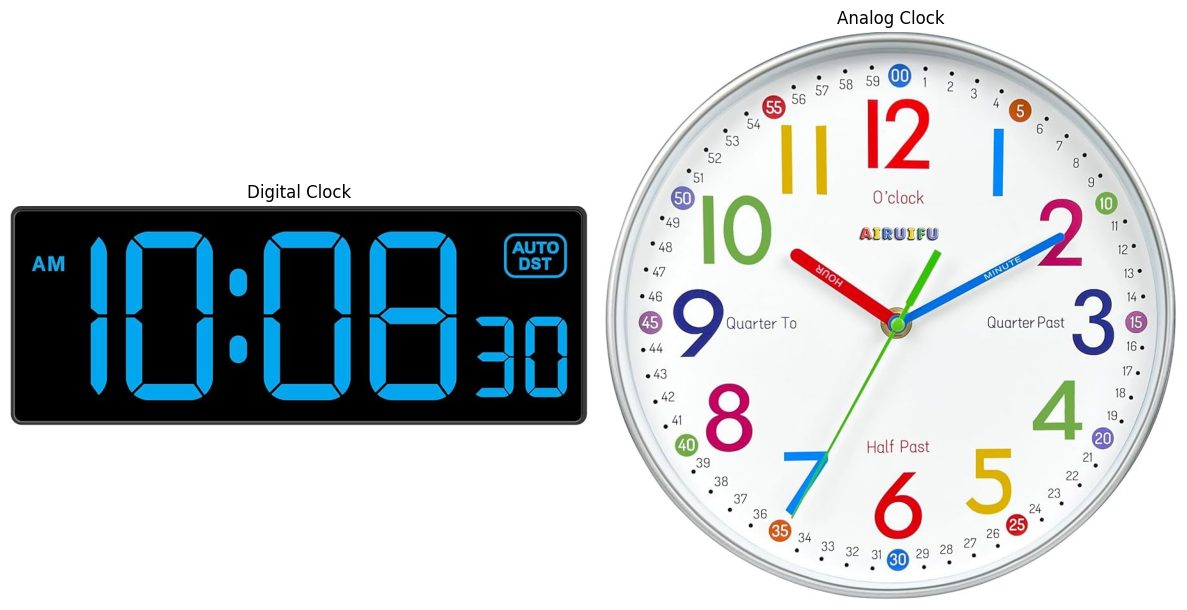

In [3]:
digital_img = Image.open(digital_clock_path)
analog_img  = Image.open(analog_clock_path)

# Create side-by-side plot
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

axes[0].imshow(digital_img)
axes[0].set_title("Digital Clock")
axes[0].axis("off")

axes[1].imshow(analog_img)
axes[1].set_title("Analog Clock")
axes[1].axis("off")

plt.tight_layout()
plt.show()

In [4]:
extractor_instance = TimeExtractor()
digital_time = extractor_instance.extract_time(digital_clock_path)
print("Digital Clock time:", digital_time)

Digital Clock time: 10:08:30


In [5]:
mask_np, _ = get_mask(
    image_path=analog_clock_path,
)

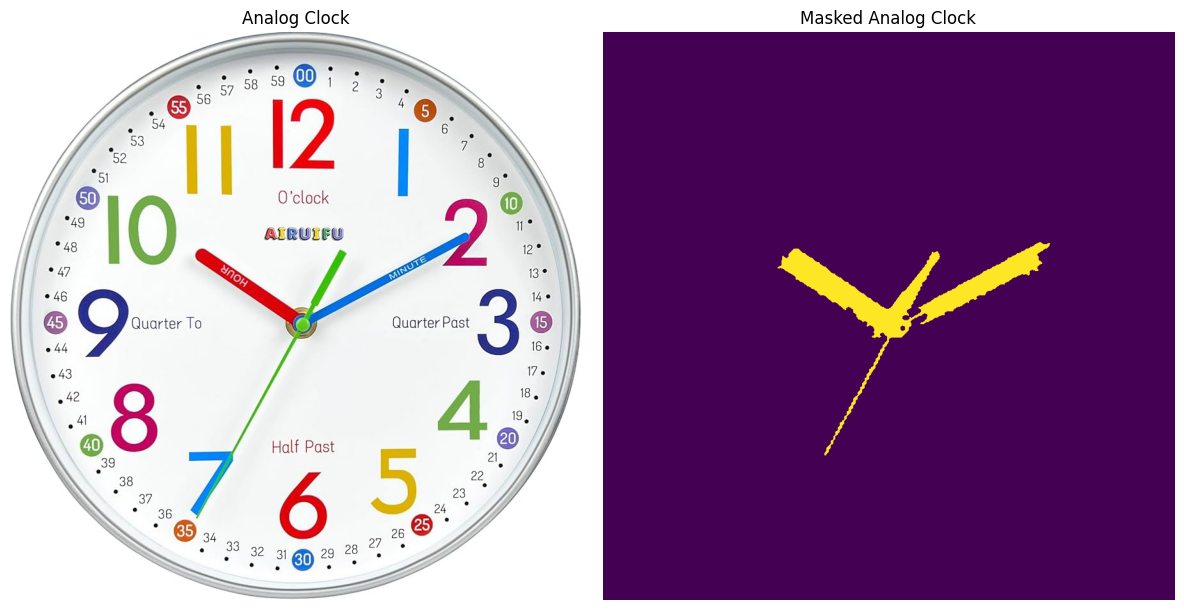

In [6]:
masked_image_pil = Image.fromarray(mask_np)

fig, axes = plt.subplots(1, 2, figsize=(12, 6))

axes[0].imshow(analog_img)
axes[0].set_title("Analog Clock")
axes[0].axis("off")

axes[1].imshow(masked_image_pil)
axes[1].set_title("Masked Analog Clock")
axes[1].axis("off")

plt.tight_layout()
plt.show()

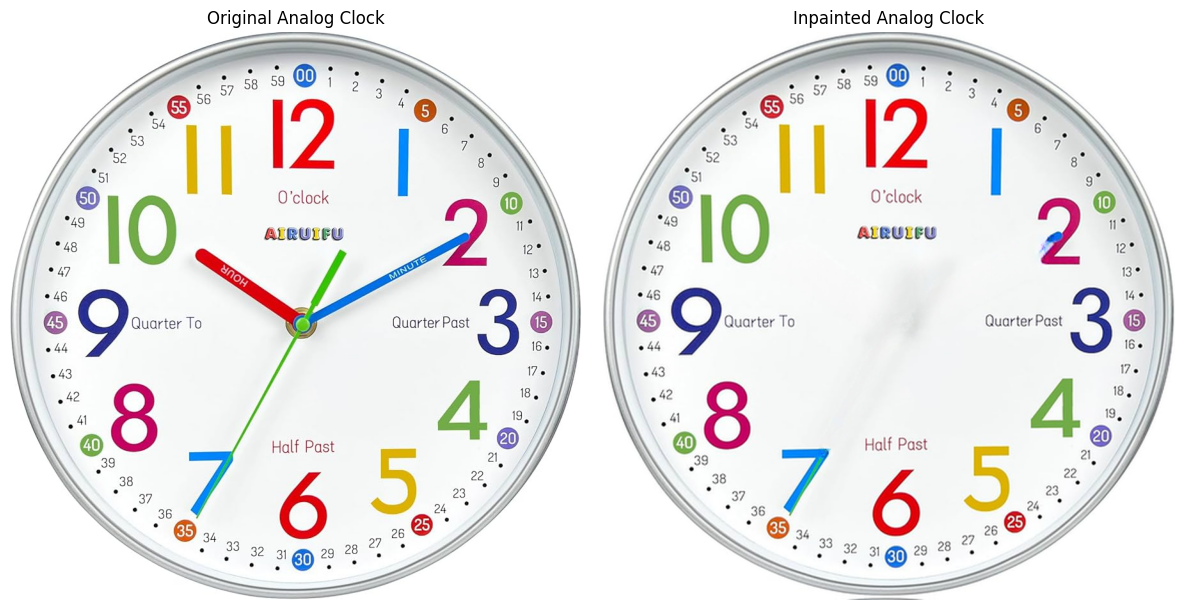

In [7]:
result_pil = inpaint_image(
    analog_clock_path,
    mask_np
)

fig, axes = plt.subplots(1, 2, figsize=(12, 6))
axes[0].imshow(analog_img)
axes[0].set_title("Original Analog Clock")
axes[0].axis("off")
axes[1].imshow(result_pil)
axes[1].set_title("Inpainted Analog Clock")
axes[1].axis("off")
plt.tight_layout()
plt.show()

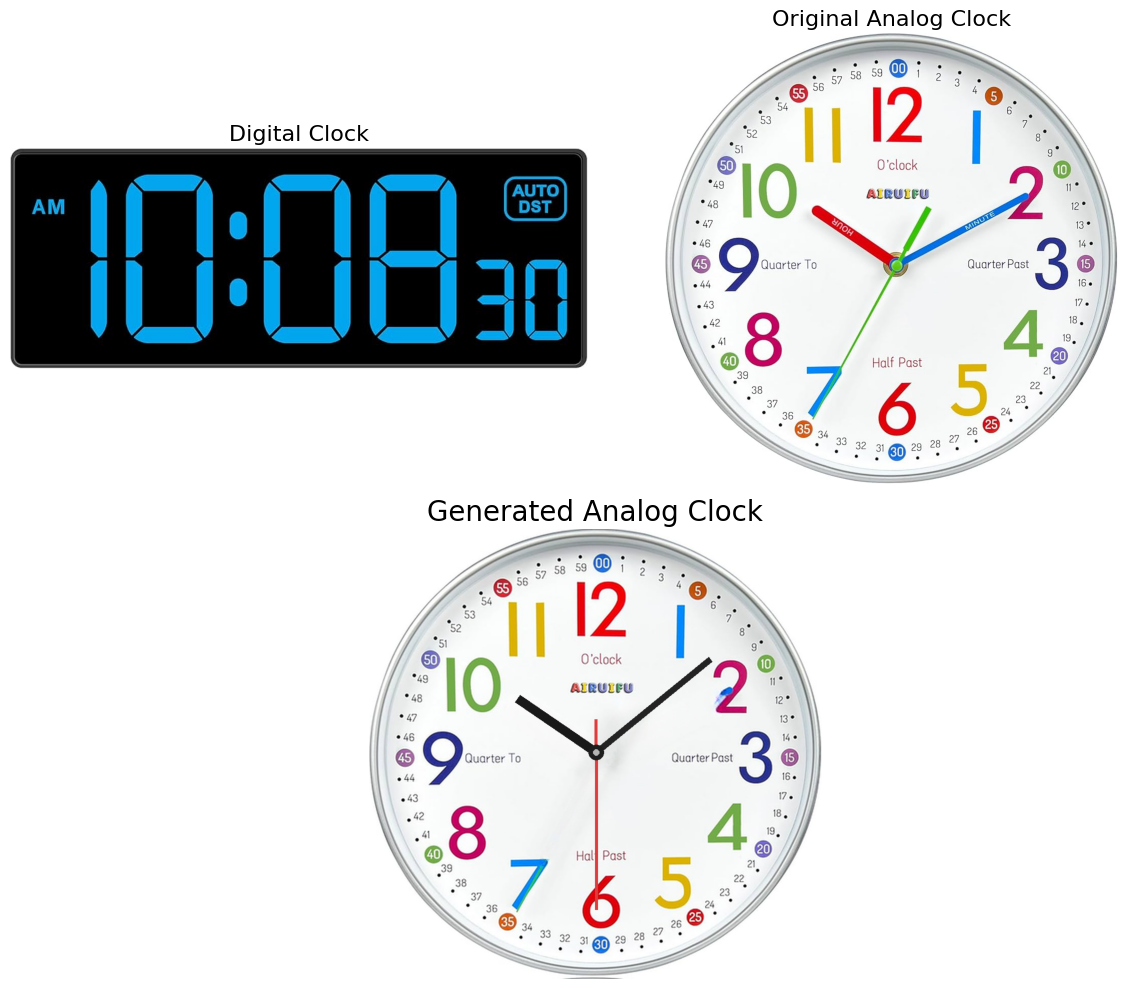

In [8]:
clock_with_hands = add_clock_hands(
    result_pil,
    digital_time
)

fig = plt.figure(figsize=(12, 10))
ax1 = plt.subplot2grid((2, 2), (0, 0))
ax2 = plt.subplot2grid((2, 2), (0, 1))

ax3 = plt.subplot2grid((2, 2), (1, 0), colspan=2)
ax1.imshow(digital_img)
ax1.set_title("Digital Clock", fontsize=16)
ax1.axis("off")
ax2.imshow(analog_img)
ax2.set_title("Original Analog Clock", fontsize=16)
ax2.axis("off")
ax3.imshow(clock_with_hands)
ax3.set_title("Generated Analog Clock", fontsize=20)
ax3.axis("off")

plt.tight_layout()
plt.show()

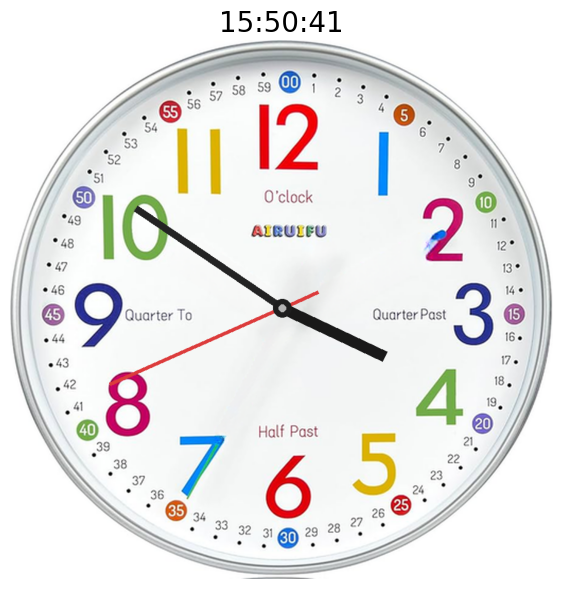

Animation finished.


In [10]:
import time
import matplotlib.pyplot as plt

from datetime import datetime
from IPython.display import clear_output


# =====================================================
# Start timer
# =====================================================
start_time = time.time()

last_second = -1

# =====================================================
# LIVE CLOCK
# =====================================================
while True:

    elapsed = time.time() - start_time

    if elapsed > 30:
        print("Animation finished.")
        break

    now = datetime.now()

    # -------------------------------------------------
    # Update ONLY when second changes
    # -------------------------------------------------
    if now.second == last_second:
        time.sleep(0.01)
        continue

    last_second = now.second

    # -------------------------------------------------
    # Time
    # -------------------------------------------------
    h = now.hour
    m = now.minute
    s = now.second

    time_str = f"{h}:{m}:{s}"

    # -------------------------------------------------
    # Draw
    # -------------------------------------------------
    frame = add_clock_hands(
        image=result_pil,
        time_str=time_str
    )

    clear_output(wait=True)

    plt.figure(figsize=(7, 7))

    plt.imshow(frame)

    plt.title(
        now.strftime("%H:%M:%S"),
        fontsize=20
    )

    plt.axis("off")

    plt.show()